# 04 · Feature Engineering

**Adds:**
- Temporal: year, month, weekday, hour, is_weekend, is_holiday
- Lags: lag1, lag6, lag12, lag24, lag48, lag168
- Rolling: rollmean24
- Weather: temperature, humidity, precipitation
  - LCL: from `weather_hourly_darksky.csv` (DarkSky export)
  - CHP: from `belgium_weather.csv` (Open-Meteo export, single Brussels station)
- TSFeatures: statistical features per unit (used for clustering AND forecasting)

**Input:** `data/output/df_hourly_{dataset}.parquet`  
**Output:** `data/output/df_features_{dataset}.parquet`  
          `data/output/tsf_features_{dataset}.parquet` (unit-level tsfeatures features for clustering)


In [1]:
import sys, os
_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root,'config')) and os.path.isdir(os.path.join(_root,'utils')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root); os.chdir(_root)

from config.settings import cfg, DATASET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from tsfeatures import tsfeatures
from tqdm import tqdm
sns.set()

print(f'Dataset : {DATASET.upper()}')

Dataset : CHP


In [2]:
in_path = os.path.join(_root, cfg['OUTPUT_DIR'], f'df_hourly_{DATASET}.parquet')
df      = pd.read_parquet(in_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values([cfg['ID_COL'], 'timestamp']).reset_index(drop=True)

ID  = cfg['ID_COL']
KWH = cfg['DEMAND_COL']

print(f'Shape        : {df.shape}')
print(f'Unique units : {df[ID].nunique()}')
print(f'Date range   : {df["timestamp"].min()} -> {df["timestamp"].max()}')

Shape        : (1698384, 4)
Unique units : 82
Date range   : 2021-01-01 00:00:00 -> 2023-05-13 23:00:00


In [3]:
# Fix duplicate file columns if present
if 'file_x' in df.columns:
    df = df.drop(columns=['file_x'])
    df = df.rename(columns={'file_y': 'file'})

## 1 · Temporal features

In [4]:
df['year']       = df['timestamp'].dt.year.astype(int)
df['month']      = df['timestamp'].dt.month.astype(int)
df['weekday']    = df['timestamp'].dt.weekday.astype(int)
df['hour']       = df['timestamp'].dt.hour.astype(int)
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

if cfg['HOLIDAY_COUNTRY'] == 'UK':
    country_holidays = holidays.UK(years=list(cfg['HOLIDAY_YEARS']))
elif cfg['HOLIDAY_COUNTRY'] == 'NL':
    country_holidays = holidays.Netherlands(years=list(cfg['HOLIDAY_YEARS']))
elif cfg['HOLIDAY_COUNTRY'] == 'BE':
    country_holidays = holidays.Belgium(years=list(cfg['HOLIDAY_YEARS']))
else:
    country_holidays = holidays.country_holidays(
        cfg['HOLIDAY_COUNTRY'], years=list(cfg['HOLIDAY_YEARS'])
    )

holiday_dates    = pd.to_datetime(list(country_holidays.keys()))
df['is_holiday'] = df['timestamp'].dt.normalize().isin(holiday_dates).astype(int)

print('Temporal features added.')

Temporal features added.


## 2 · Lag features

In [5]:
for lag in [1, 6, 12, 24, 48, 168]:
    df[f'{KWH}_lag{lag}'] = df.groupby(ID)[KWH].shift(lag)

df[f'{KWH}_rollmean24'] = (
    df.groupby(ID)[KWH]
    .transform(lambda x: x.shift(1).rolling(window=24, min_periods=12).mean())
)


## 3 · Weather

LCL uses a DarkSky-format hourly file with multiple variables. CHP uses an Open-Meteo
hourly export for a single Brussels station; the file has a 3-row metadata header
followed by `time, temperature_2m, relative_humidity_2m, precipitation`.

Weather is broadcast across all units in a dataset (single station per dataset).


In [6]:
df

,chp_id,timestamp,production_mwh,capacity_mw,year,month,weekday,hour,is_weekend,is_holiday,production_mwh_lag1,production_mwh_lag6,production_mwh_lag12,production_mwh_lag24,production_mwh_lag48,production_mwh_lag168,production_mwh_rollmean24
0,1344,2021-01-01 00:00:00,9.000,9.000,2021,1,4,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1344,2021-01-01 01:00:00,9.000,9.000,2021,1,4,1,0,1,9.000,NaN,NaN,NaN,NaN,NaN,NaN
2,1344,2021-01-01 02:00:00,9.000,9.000,2021,1,4,2,0,1,9.000,NaN,NaN,NaN,NaN,NaN,NaN
3,1344,2021-01-01 03:00:00,8.734,9.000,2021,1,4,3,0,1,9.000,NaN,NaN,NaN,NaN,NaN,NaN
4,1344,2021-01-01 04:00:00,8.582,9.000,2021,1,4,4,0,1,8.734,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698379,960,2023-05-13 19:00:00,6.221,9.973,2023,5,5,19,1,0,6.029,5.708,6.077,6.572,6.135,6.327,5.899042
1698380,960,2023-05-13 20:00:00,6.353,9.973,2023,5,5,20,1,0,6.221,5.999,6.351,6.415,6.237,6.613,5.884417
1698381,960,2023-05-13 21:00:00,6.548,9.973,2023,5,5,21,1,0,6.353,6.228,6.065,6.397,6.049,6.909,5.881833
1698382,960,2023-05-13 22:00:00,6.178,9.973,2023,5,5,22,1,0,6.548,6.318,5.780,6.325,6.137,6.343,5.888125


In [7]:
import pandas as pd
weather_path = os.path.join(_root, cfg['WEATHER_FILE'])
raw = pd.read_csv(weather_path, skiprows=3)
print(f'Total rows: {len(raw)}')
print(f'\nRows around position 20712:')
print(raw.iloc[20708:20720])
print(f'\nLast 5 rows:')
print(raw.tail())

Total rows: 21576

Rows around position 20712:
                   time       temperature_2m (°C)  relative_humidity_2m (%)  \
20708  2023-05-13T20:00                      17.0                      71.0   
20709  2023-05-13T21:00                      15.4                      82.0   
20710  2023-05-13T22:00                      13.7                      90.0   
20711  2023-05-13T23:00                      12.9                      92.0   
20712              time  temperature_2m_mean (°C)                       NaN   
20713        2021-01-01                       0.6                       NaN   
20714        2021-01-02                       1.1                       NaN   
20715        2021-01-03                       2.0                       NaN   
20716        2021-01-04                       1.6                       NaN   
20717        2021-01-05                       1.9                       NaN   
20718        2021-01-06                       1.9                       NaN   
20719

In [8]:
def _floor_hour(ts):
    return pd.to_datetime(ts).dt.floor('h')

if DATASET == 'lcl' and cfg.get('WEATHER_FILE') is not None:
    weather_path = os.path.join(_root, cfg['WEATHER_FILE'])
    weather      = pd.read_csv(weather_path, parse_dates=['time'], index_col='time')
    weather.index.name = 'timestamp'
    weather      = weather[['temperature']].reset_index()
    weather['timestamp'] = _floor_hour(weather['timestamp'])
    weather      = weather.groupby('timestamp')['temperature'].mean().reset_index()
    weather_cols = ['temperature']

    df = df.merge(weather, on='timestamp', how='left')

elif DATASET == 'chp' and cfg.get('WEATHER_FILE') is not None:
    weather_path = os.path.join(_root, cfg['WEATHER_FILE'])
    weather      = pd.read_csv(weather_path, skiprows=3)

    # Drop any row where 'time' is a header repeat or NaN (Open-Meteo
    # sometimes appends daily aggregates after the hourly block)
    weather = weather[weather['time'].notna() & (weather['time'] != 'time')]

    # Robust to mixed ISO8601 formats
    weather['time'] = pd.to_datetime(weather['time'], format='ISO8601', errors='coerce')
    weather = weather.dropna(subset=['time'])

    rename_map = {
        'time'                                 : 'timestamp',
        'temperature_2m (\u00b0C)'             : 'temperature',
        'relative_humidity_2m (%)'             : 'humidity',
        'precipitation (mm)'                   : 'precipitation',
        'wind_speed_100m (km/h)'               : 'wind_speed_100m',
        'wind_speed_10m (km/h)'                : 'wind_speed_10m',
        'direct_radiation_instant (W/m\u00b2)' : 'direct_radiation',
    }
    weather = weather.rename(columns=rename_map)
    weather['timestamp'] = pd.to_datetime(weather['timestamp']).dt.floor('h')

    weather_cols = [c for c in
                    ['temperature', 'humidity', 'precipitation',
                     'wind_speed_100m', 'wind_speed_10m', 'direct_radiation']
                    if c in weather.columns]

    # Coerce numerics — they may have come in as strings if a header row leaked in
    for c in weather_cols:
        weather[c] = pd.to_numeric(weather[c], errors='coerce')

    weather = weather[['timestamp'] + weather_cols].drop_duplicates('timestamp')
    df = df.merge(weather, on='timestamp', how='left')



In [9]:
# Per-unit interpolation to fill the small gaps that arise from timezone/DST edges
df = df.sort_values([ID, 'timestamp'])
for c in weather_cols:
    df[c] = df.groupby(ID)[c].transform(
        lambda x: x.interpolate(method='linear', limit=24)
    )

if weather_cols:
    nan_summary = df[weather_cols].isna().sum().to_dict()
    print(f'Weather merged. Variables ({len(weather_cols)}): {weather_cols}')
    print(f'Remaining NaNs per column: {nan_summary}')
else:
    print('No weather variables added.')

Weather merged. Variables (6): ['temperature', 'humidity', 'precipitation', 'wind_speed_100m', 'wind_speed_10m', 'direct_radiation']
Remaining NaNs per column: {'temperature': 0, 'humidity': 0, 'precipitation': 0, 'wind_speed_100m': 0, 'wind_speed_10m': 0, 'direct_radiation': 0}


## 4 · Drop lag warmup period

In [10]:
n_before  = len(df)
lag_cols  = [f'{KWH}_lag{lag}' for lag in [24, 48, 168]]
drop_cols = lag_cols + [f'{KWH}_rollmean24']
df        = df.dropna(subset=drop_cols)

print(f'Rows dropped (warmup): {n_before - len(df):,}')
print(f'Rows remaining       : {len(df):,}')


Rows dropped (warmup): 13,776
Rows remaining       : 1,684,608


## 5 · tsfeatures (Nixtla)

tsfeatures extracts ~60 curated statistical features from each unit's time series.
Used for both clustering (notebook 08) and as static forecast covariates.
Features are extracted from the TRAINING period only to avoid data leakage.

In [11]:
train_end  = df['timestamp'].min() + pd.DateOffset(months=cfg['TRAIN_MONTHS'])
train_df   = df[df['timestamp'] < train_end]

print(f'Split date : {train_end}')
print(f'Train rows : {len(train_df):,}')
print(f'Extracting tsfeatures from training period only...')

Split date : 2022-01-08 00:00:00
Train rows : 718,320
Extracting tsfeatures from training period only...


In [12]:
# tsfeatures expects columns: unique_id, ds, y
tsf_input = train_df[[ID, 'timestamp', KWH]].copy()
tsf_input.columns = ['unique_id', 'ds', 'y']

from tsfeatures import (
    acf_features, arch_stat, crossing_points,
    entropy, flat_spots, heterogeneity,
    holt_parameters, lumpiness, nonlinearity,
    pacf_features, stl_features, stability,
    sparsity, unitroot_kpss, unitroot_pp
)

FREQ = 24 if cfg['FREQ'] in ['h', 'H'] else 48

safe_features = [
    acf_features, arch_stat, crossing_points,
    entropy, flat_spots, heterogeneity,
    lumpiness, nonlinearity, pacf_features,
    stability, sparsity, stl_features,
    unitroot_kpss, unitroot_pp
]

tsf_df = tsfeatures(
    tsf_input,
    freq=FREQ,
    features=safe_features
)



/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/linear_mo

In [13]:
tsf_df = tsf_df.reset_index()

# Drop 'index' column if it snuck in
if 'index' in tsf_df.columns:
    tsf_df = tsf_df.drop(columns=['index'])

tsf_df = tsf_df.rename(columns={'unique_id': ID})
tsf_df = tsf_df.dropna(axis=1, how='all')
tsf_df = tsf_df.loc[:, tsf_df.nunique() > 1]
tsf_df = tsf_df.fillna(0)

# tsf_cols = feature columns only (exclude the ID column)
tsf_cols = [c for c in tsf_df.columns if c != ID]

print(f'tsfeatures shape : {tsf_df.shape}')
print(f'Feature cols     : {tsf_cols}')
tsf_df.head(3)

tsfeatures shape : (82, 30)
Feature cols     : ['unitroot_pp', 'unitroot_kpss', 'trend', 'spike', 'linearity', 'curvature', 'e_acf1', 'e_acf10', 'seasonal_strength', 'peak', 'trough', 'stability', 'x_pacf5', 'diff1x_pacf5', 'diff2x_pacf5', 'seas_pacf', 'nonlinearity', 'lumpiness', 'flat_spots', 'entropy', 'crossing_points', 'arch_lm', 'x_acf1', 'x_acf10', 'diff1_acf1', 'diff1_acf10', 'diff2_acf1', 'diff2_acf10', 'seas_acf1']


,chp_id,unitroot_pp,unitroot_kpss,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,1344,-160.844604,1.870175,0.928554,1.040510e-09,-12.722708,7.342859,0.687994,0.897917,0.208792,...,0.516358,0,0.952821,0.973076,8.062740,-0.021623,0.023290,-0.446078,0.210380,0.747096
1,1636,-22.657601,20.648014,0.992009,2.840011e-11,41.721731,3.481961,0.819741,1.345003,0.236768,...,0.253045,345,0.994810,0.997925,9.718996,0.204013,0.052676,-0.317461,0.180501,0.940484
2,16860,-83.536552,9.068467,0.966511,1.309674e-10,-34.246554,-11.196673,0.798180,1.220451,0.230149,...,0.469254,189,0.945355,0.991197,8.936033,0.200368,0.050904,-0.333613,0.144244,0.806745


In [14]:
tsf_cols = [c for c in tsf_df.columns if c != ID]
df = df.merge(tsf_df, on=ID, how='left')

print(f'tsfeature cols added : {len(tsf_cols)}')
print(f'df shape after join  : {df.shape}')
print(f'NaNs in tsf cols     : {df[tsf_cols].isna().sum().sum()}')

tsfeature cols added : 29
df shape after join  : (1684608, 52)
NaNs in tsf cols     : 0


## 6 · Build final feature list

In [15]:
manual_features = cfg['FEATURES_MANUAL']

# Add any weather columns that were actually merged in this dataset
manual_features = manual_features + [c for c in weather_cols if c not in manual_features]

# Add tsfeatures columns
all_features = [f for f in manual_features if f in df.columns] + \
               [f for f in tsf_cols if f in df.columns]

cfg['FEATURES'] = all_features
print(f'Total features  : {len(all_features)}')
print(f'Manual+weather  : {len([f for f in manual_features if f in df.columns])}')
print(f'  of which weather: {len([c for c in weather_cols if c in df.columns])}')
print(f'tsfeatures      : {len(tsf_cols)}')


Total features  : 39
Manual+weather  : 10
  of which weather: 6
tsfeatures      : 29


## 7 · Sanity check

Top 15 features by |correlation| with target:
production_mwh_lag24     0.940
production_mwh_lag168    0.876
e_acf10                  0.393
e_acf1                   0.346
lumpiness                0.319
seasonal_strength        0.302
arch_lm                  0.292
x_acf10                  0.257
curvature                0.255
x_pacf5                  0.235
stability                0.235
trend                    0.218
seas_pacf                0.217
x_acf1                   0.210
peak                     0.207


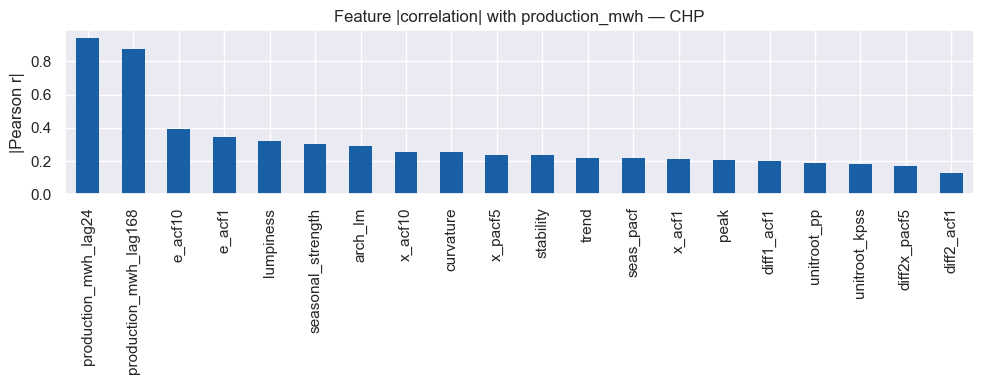

In [16]:
# Correlation of features with target
corr = df[all_features + [KWH]].corr()[KWH].drop(KWH).abs().sort_values(ascending=False)

print('Top 15 features by |correlation| with target:')
print(corr.head(15).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
corr.head(20).plot(kind='bar', ax=ax, color='#185FA5', edgecolor='none')
ax.set_title(f'Feature |correlation| with {KWH} — {DATASET.upper()}')
ax.set_ylabel('|Pearson r|')
plt.tight_layout()
plt.show()

## Save

In [17]:
out_dir = os.path.join(_root, cfg['OUTPUT_DIR'])

# Main features file — used by forecast and reconciliation notebooks
out_features = os.path.join(out_dir, f'df_features_{DATASET}.parquet')
df.to_parquet(out_features, index=False)
print(f'Saved -> {out_features}  ({os.path.getsize(out_features)/1e6:.1f} MB)')

# Save tsfeatures for clustering notebook
out_tsf = os.path.join(out_dir, f'tsf_features_{DATASET}.parquet')
tsf_df.to_parquet(out_tsf, index=False)
print(f'Saved -> {out_tsf}')

# Save final feature list for downstream notebooks
import json
feat_path = os.path.join(out_dir, f'feature_list_{DATASET}.json')
with open(feat_path, 'w') as f:
    json.dump(all_features, f)
print(f'Saved -> {feat_path}')

# Read-back
check = pd.read_parquet(out_features)
print(f'Read-back: {check.shape} | NaNs in features: {check[all_features].isna().sum().sum()}')
check.head(3)

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/df_features_chp.parquet  (42.1 MB)
Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/tsf_features_chp.parquet
Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/feature_list_chp.json
Read-back: (1684608, 52) | NaNs in features: 0


,chp_id,timestamp,production_mwh,capacity_mw,year,month,weekday,hour,is_weekend,is_holiday,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,1344,2021-01-08 00:00:00,9.00,9.0,2021,1,4,0,0,0,...,0.516358,0,0.952821,0.973076,8.06274,-0.021623,0.02329,-0.446078,0.21038,0.747096
1,1344,2021-01-08 01:00:00,7.42,9.0,2021,1,4,1,0,0,...,0.516358,0,0.952821,0.973076,8.06274,-0.021623,0.02329,-0.446078,0.21038,0.747096
2,1344,2021-01-08 02:00:00,9.00,9.0,2021,1,4,2,0,0,...,0.516358,0,0.952821,0.973076,8.06274,-0.021623,0.02329,-0.446078,0.21038,0.747096


In [18]:
print (check.columns)

Index(['chp_id', 'timestamp', 'production_mwh', 'capacity_mw', 'year', 'month',
       'weekday', 'hour', 'is_weekend', 'is_holiday', 'production_mwh_lag1',
       'production_mwh_lag6', 'production_mwh_lag12', 'production_mwh_lag24',
       'production_mwh_lag48', 'production_mwh_lag168',
       'production_mwh_rollmean24', 'temperature', 'humidity', 'precipitation',
       'wind_speed_100m', 'wind_speed_10m', 'direct_radiation', 'unitroot_pp',
       'unitroot_kpss', 'trend', 'spike', 'linearity', 'curvature', 'e_acf1',
       'e_acf10', 'seasonal_strength', 'peak', 'trough', 'stability',
       'x_pacf5', 'diff1x_pacf5', 'diff2x_pacf5', 'seas_pacf', 'nonlinearity',
       'lumpiness', 'flat_spots', 'entropy', 'crossing_points', 'arch_lm',
       'x_acf1', 'x_acf10', 'diff1_acf1', 'diff1_acf10', 'diff2_acf1',
       'diff2_acf10', 'seas_acf1'],
      dtype='object')
